In [ ]:
from src.EPInformer.models_abc import EPInformer_v1, enhancer_predictor_256bp, MoPInformer
from src.scripts.utils import prepare_input
import src.scripts.utils_forTraining as train
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from tqdm import tqdm
import torch
from torch.utils.data import Subset, Dataset
import torch.utils.data as data_utils
from sklearn.metrics import mean_squared_error
import h5py
import kipoiseq

In [3]:
# # Download GM12878 data from Zenodo
# !wget https://zenodo.org/records/12738705/files/K562_DNase_ENCFF257HEE_2kb_4DNFITUOMFUQ_enhancer_promoter_encoding.h5.zip -P ./data/
# !wget https://zenodo.org/records/12738705/files/K562_DNase_ENCFF257HEE_hic_4DNFITUOMFUQ_1MB_ABC_nominated.zip -P ./data/
# !unzip -o -qq ./data/K562_DNase_ENCFF257HEE_2kb_4DNFITUOMFUQ_enhancer_promoter_encoding.h5.zip -d ./data/
# !unzip -o -qq ./data/K562_DNase_ENCFF257HEE_hic_4DNFITUOMFUQ_1MB_ABC_nominated.zip -d ./data/

In [ ]:
class promoter_enhancer_dataset(Dataset):
    def __init__(self, data_dir, cell_type='K562', expr_type='RNA', n_enh_feats=3, disable_enh=False, distance_thr=None, max_n_enh=200, use_prm_signal=False, rm_prm_seq=False, motif_feat_path=None):
        # self.data_h5 = h5py.File('/mnt/usb1/jiecong/{}_220CREs-gene_strand.hdf5'.format(cell_type), 'r') # /mnt/usb1/jiecong
        self.data_h5 = h5py.File(data_dir + '/{}_200CREs-gene_RPM_4feats.hdf5'.format(cell_type), 'r')
        self.rm_prm_seq = rm_prm_seq
        self.cell_type = cell_type
        self.n_enh_feats = n_enh_feats
        self.expr_type = expr_type
        self.disable_enh = disable_enh
        self.distance_thr = distance_thr
        self.max_n_enh = max_n_enh
        self.use_prm_signal = use_prm_signal
        # self.expr_df = pd.read_csv('./data/GM12878_K562_18377_gene_expr_fromXpresso.csv', index_col='gene_id')
        self.expr_df = pd.read_csv('./data/GM12878_K562_18377_gene_expr_fromXpresso_with_sequence_strand.csv', index_col='gene_id')
        # self.cell2tok = {'K562':0, 'GM12878':1, 'HepG2':2,}
        if cell_type == 'K562':
            promoter_df = pd.read_csv(data_dir + '/K562_ABC_EGLinks/DNase_ENCFF257HEE_Neighborhoods/GeneList.txt', sep='\t', index_col='name')
        elif cell_type == 'GM12878':
            promoter_df = pd.read_csv(data_dir + '/GM12878_ABC_EGLinks/DNase_ENCFF020WZB_Neighborhoods/GeneList.txt', sep='\t', index_col='name')
        elif cell_type == 'HepG2':
            promoter_df = pd.read_csv(data_dir + '/HepG2_ABC_EGLinks/DNase_ENCFF691HJY_Neighborhoods/GeneList.txt', sep='\t', index_col='name')
        else:
            print('Cell not found!')
        promoter_df['promoter_activity'] = np.sqrt(promoter_df['DHS.RPKM.TSS1Kb']*promoter_df['H3K27ac.RPKM.TSS1Kb'])
        self.promoter_df = promoter_df
        self.motif_df = None
        self.motif_feat_dim = 0
        if motif_feat_path is not None:
            try:
                motif_df = pd.read_csv(motif_feat_path, sep='\t', comment='#', index_col=0, engine='python')
            except Exception:
                motif_df = pd.read_csv(motif_feat_path, sep='\t', index_col=0, engine='python')
            motif_df = motif_df.apply(pd.to_numeric, errors='coerce').fillna(0.0)
            self.motif_df = motif_df
            self.motif_feat_dim = motif_df.shape[1]

    def __len__(self):
        return len(self.data_h5['ensid'])
    def __getitem__(self, idx):
        sample_ensid = self.data_h5['ensid'][idx].decode()
        enh_ohe = self.data_h5['enhancers_ohe'][idx]
        enh_feats = self.data_h5['enhancers_feat'][idx][:,:]
        prm_seq = self.expr_df.loc[sample_ensid, 'promoter_2k']
        prm_ohe = one_hot_encode(prm_seq)[np.newaxis,:]
        prm_signal = np.log(1+np.array([self.promoter_df.loc[sample_ensid, 'promoter_activity']]))
        if self.n_enh_feats == 0:
            enh_feats = np.zeros_like(np.concatenate([abs(enh_feats[:, [0]]), enh_feats[:, [3]], enh_feats[:, [-1]]], axis=1)[:,:1])
        else:
            enh_feats = np.concatenate([abs(enh_feats[:, [0]]), enh_feats[:, [3]], enh_feats[:, [-1]]], axis=1)[:,:self.n_enh_feats]
        rna_feats = np.array(self.expr_df.loc[sample_ensid][['UTR5LEN_log10zscore','CDSLEN_log10zscore','INTRONLEN_log10zscore',
                             'UTR3LEN_log10zscore','UTR5GC','CDSGC','UTR3GC', 'ORFEXONDENSITY']].values.astype(float)).flatten()
        if self.use_prm_signal:
            rna_feats = np.concatenate([rna_feats, prm_signal])
        if self.distance_thr is not None: 
            enh_ohe_new = np.zeros((self.max_n_enh, 2000, 4))
            enh_feats_new = np.zeros((self.max_n_enh, enh_feats.shape[-1]))
            new_i = 0
            for i in range(enh_ohe.shape[0]):
                if not self.rm_prm_seq:
                    if abs(enh_feats[i][0])<=self.distance_thr:
                        # enh_ohe[i] = np.zeros_like(enh_ohe[i])
                        enh_ohe_new[new_i] = enh_ohe[i]
                        enh_feats_new[new_i] = enh_feats[i]
                        new_i += 1
                else:
                    if abs(enh_feats[i][0])<=self.distance_thr and abs(enh_feats[i][0])>=1000:
                        # enh_ohe[i] = np.zeros_like(enh_ohe[i])
                        enh_ohe_new[new_i] = enh_ohe[i]
                        enh_feats_new[new_i] = enh_feats[i]
                        new_i += 1
                if new_i >= self.max_n_enh:
                    break
            enh_ohe = enh_ohe_new
            enh_feats = enh_feats_new
        if self.disable_enh:
            enh_ohe = np.zeros_like(enh_ohe)
            enh_feats = np.zeros_like(enh_feats)
        if self.expr_type == 'CAGE':
            expr = np.log10(self.expr_df.loc[sample_ensid, self.cell_type + '_CAGE_128*3_sum']+1)
        else:
            expr = self.expr_df.loc[sample_ensid, 'Actual_' + self.cell_type]
        pe_ohe = np.concatenate([prm_ohe, enh_ohe], axis=0)
        prm_feats = np.ones_like(enh_feats[[0]])
        if self.use_prm_signal and self.n_enh_feats == 3:
            prm_feats[0, 1] = prm_signal
        pe_feats = np.concatenate([prm_feats, enh_feats], axis=0)

        if self.motif_df is not None and sample_ensid in self.motif_df.index:
            motif_feats = self.motif_df.loc[sample_ensid].values.astype(np.float32)
            return pe_ohe, rna_feats, pe_feats, motif_feats, expr, sample_ensid

        return pe_ohe, rna_feats, pe_feats, expr, sample_ensid

def test(net, test_ds, fold_i, model_name = None, saved_model_path=None, batch_size=64, device='cuda', model_type='best'):
    testloader = data_utils.DataLoader(test_ds, batch_size=batch_size, pin_memory=True, num_workers=0)
    if saved_model_path is not None:
        checkpoint = torch.load(saved_model_path + "/fold_" + str(fold_i) + "_best_"+model_name+"_checkpoint.pt", weights_only=False)
        net.load_state_dict(checkpoint['model_state_dict'])
        print(model_name,'loaded!')
    net.eval()
    with torch.no_grad():
        preds = []
        actual = []
        ensid_list = []
        for data in tqdm(testloader):
            motif_feats = None
            if len(data) == 6:
                pe_seqs, rna_feats, enh_feats, motif_feats, y_expr, eid = data
            else:
                pe_seqs, rna_feats, enh_feats, y_expr, eid = data

            pe_seqs = pe_seqs.float().to(device)
            if net.useFeat:
                rna_feats = rna_feats.float().to(device)
            else:
                rna_feats = None
            enh_feats = enh_feats.float().to(device)
            y_expr = y_expr.float().to(device)

            if motif_feats is not None:
                motif_feats = motif_feats.float().to(device)
                pred_expr, _ = net(pe_seqs, enh_feats=enh_feats, rna_feats=rna_feats, motif_feats=motif_feats)
            else:
                pred_expr, _ = net(pe_seqs, enh_feats=enh_feats, rna_feats=rna_feats)

            outputs = list(pred_expr.flatten().cpu().detach().numpy())
            labels = list(y_expr.flatten().cpu().detach().numpy())
            preds += outputs
            actual += labels
            ensid_list += eid

    slope, intercept, r_value, p_value, std_err = stats.linregress(preds, actual)
    peasonr, pvalue = stats.pearsonr(preds, actual)
    mse = mean_squared_error(preds, actual)
    # print(fold %s test sequence: %0.3f' % (fold_i, r_value**2))
    print('\nPearson R:', peasonr)
    # sys.stdout.flush()
    df = pd.DataFrame(index=np.array(ensid_list).flatten())
    df['Pred'] = preds
    df['actual'] = actual
    df['fold_idx'] = fold_i
    pearsonr_we, pvalue = stats.pearsonr(df['Pred'], df['actual'])
    # print('PearsonR:', pearsonr_we)
    if saved_model_path is not None:
        df.to_csv(saved_model_path + "/fold_" + str(fold_i) + "_"+ model_name + "_predictions.csv")
    return df

def one_hot_encode(sequence):
    return kipoiseq.transforms.functional.one_hot_dna(sequence, neutral_value=0.0).astype(np.float32)

In [5]:
# Download K562 training data from Zenodo 
# !wget https://zenodo.org/records/13233337/files/K562_200CREs-gene_RPM_4feats.hdf5.gz -P ./data/
# !wget https://zenodo.org/records/13233337/files/K562_ABC_EGLinks.zip -P ./data/
# !gunzip -o -qq ./data/K562_200CREs-gene_RPM_4feats.hdf5.gz -d ./data/
# !unzip -o -qq ./data/K562_ABC_EGLinks.zip -d ./data/

## Predict K562 CAGE/RNA-seq expression using MoPInformer

In [ ]:
cell = 'K562'
split_df = pd.read_csv('./data/leave_chrom_out_crossvalidation_split_18377genes.csv', index_col=0)
distance_threshold = 100_000
n_enhancers = 60
device = 'cuda' if torch.cuda.is_available() else 'cpu'
batch_size = 16
expr_types = ['RNA'] # ['CAGE', 'RNA']
prediction_res = []
data_dir = './data'
model_type = 'MoPInformer'
model_folder = f'./results/{model_type}'
motif_path = './data/promoter_2k_motif_hits.tsv'

for expr_type in expr_types:
    for fi in range(1, 13):
        print('cell', cell, 'expression type:', expr_type)
        print('-' * 10, 'fold', fi, '-' * 10)
        fold_i = 'fold_' + str(fi)
        train_ensid = split_df[split_df[fold_i] == 'train'].index
        valid_ensid = split_df[split_df[fold_i] == 'valid'].index
        test_ensid = split_df[split_df[fold_i] == 'test'].index

        model_name = f"{model_type}.K562.{expr_type}.60enhs.3feats.rnafeats.nonprmsig.nonrmprmseq.100kb2TSS"
        ckpt_path = f"{model_folder}/fold_{fi}_best_{model_name}_checkpoint.pt"
        checkpoint = torch.load(ckpt_path, weights_only=False, map_location=device)

        # Infer feature dimensions from checkpoint to avoid shape mismatch.
        n_extra_feat = checkpoint['model_state_dict']['add_pos_conv.0.weight'].shape[1] - 64
        motif_feat_dim = checkpoint['model_state_dict']['motif_encoder.0.weight'].shape[1]

        all_ds = promoter_enhancer_dataset(
            data_dir=data_dir,
            cell_type=cell,
            expr_type=expr_type,
            n_enh_feats=n_extra_feat,
            distance_thr=distance_threshold,
            max_n_enh=n_enhancers,
            use_prm_signal=False,
            motif_feat_path=motif_path
        )
        if all_ds.motif_feat_dim != motif_feat_dim:
            print(f"Warning: motif dim mismatch (dataset={all_ds.motif_feat_dim}, checkpoint={motif_feat_dim})")

        ensid_list = [eid.decode() for eid in all_ds.data_h5['ensid'][:]]
        ensid_df = pd.DataFrame(ensid_list, columns=['ensid'])
        ensid_df['idx'] = np.arange(len(ensid_list))
        ensid_df = ensid_df.set_index('ensid')

        train_idx = ensid_df.loc[train_ensid]['idx']
        valid_idx = ensid_df.loc[valid_ensid]['idx']
        test_idx = ensid_df.loc[test_ensid]['idx']

        train_ds = Subset(all_ds, train_idx)
        valid_ds = Subset(all_ds, valid_idx)
        test_ds = Subset(all_ds, test_idx)

        model = MoPInformer(
            n_encoder=3,
            n_enhancer=n_enhancers,
            out_dim=64,
            n_extraFeat=n_extra_feat,
            useBN=False,
            device=device,
            usePromoterSignal=False,
            useFeat=True,
            motif_feat_dim=motif_feat_dim
        ).to(device)

        model.load_state_dict(checkpoint['model_state_dict'])

        test_df = test(model, test_ds, fold_i=fi, batch_size=batch_size, device=device)
        test_df['expr_type'] = expr_type
        prediction_res.append(test_df)

prediction_res = pd.concat(prediction_res)

cell K562 expression type: RNA
---------- fold 1 ----------


100%|██████████| 137/137 [00:15<00:00,  8.67it/s]



Pearson R: 0.8720288
cell K562 expression type: RNA
---------- fold 2 ----------


100%|██████████| 83/83 [00:08<00:00,  9.53it/s]



Pearson R: 0.889073
cell K562 expression type: RNA
---------- fold 3 ----------


...


Pearson R: 0.8713535
cell K562 expression type: RNA
---------- fold 11 ----------


100%|██████████| 73/73 [00:06<00:00, 11.47it/s]



Pearson R: 0.79784703
cell K562 expression type: RNA
---------- fold 12 ----------


100%|██████████| 119/119 [00:10<00:00, 11.74it/s]


Pearson R: 0.88716847


In [14]:
prediction_res_gene = prediction_res.merge(split_df[['Gene name']], left_index=True, right_index=True).reset_index()

<Figure size 600x600 with 0 Axes>

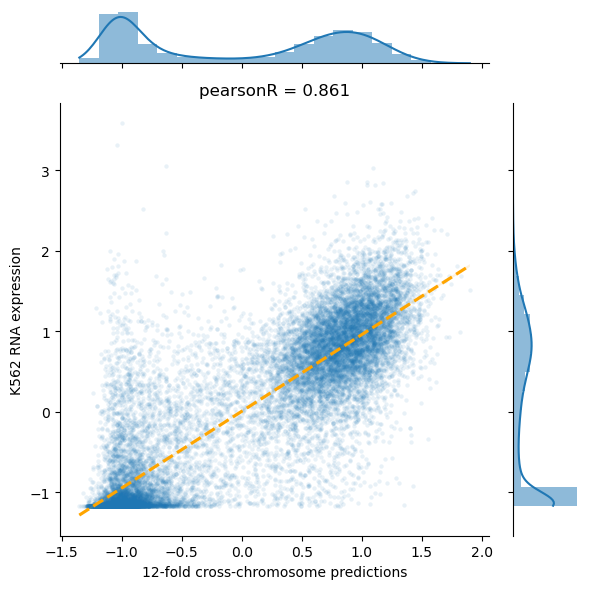

In [ ]:
plt.figure(figsize=(6,6))
expr_type = 'RNA'
prediction_assay_spec = prediction_res[prediction_res['expr_type']==expr_type].reset_index(drop=True)
pearsonR, pv = stats.pearsonr(prediction_assay_spec['Pred'], prediction_assay_spec['actual'])
ax = sns.jointplot(
    data=prediction_assay_spec,
    x="Pred",
    y="actual",
    kind = 'scatter',
    joint_kws={'marker':'o', 's':10, 'alpha':0.1, 'linewidth':0},
    marginal_kws={'bins':20, 'element':'step', 'kde':True, 'linewidth':0},
)
ax.plot_joint(sns.regplot, color="r", scatter=False, line_kws={"color": "orange", 'linestyle':'dashed'})
plt.title('pearsonR = {:.3f}'.format(pearsonR))
plt.ylabel('K562 {} expression'.format(expr_type))
plt.xlabel('12-fold cross-chromosome predictions')
plt.tight_layout()
plt.savefig('{}/RNA.png'.format(model_folder), bbox_inches='tight', dpi=600)

<Figure size 600x600 with 0 Axes>

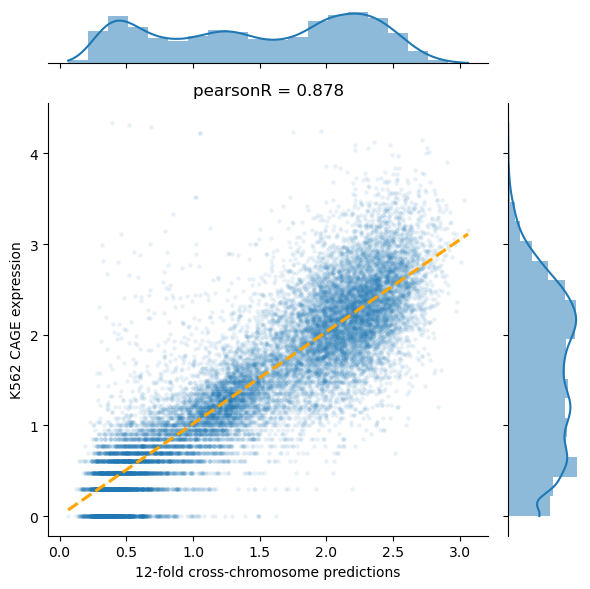

In [ ]:
plt.figure(figsize=(6,6))
expr_type = 'CAGE'
prediction_assay_spec = prediction_res[prediction_res['expr_type']==expr_type].reset_index(drop=True)
pearsonR, pv = stats.pearsonr(prediction_assay_spec['Pred'], prediction_assay_spec['actual'])
ax = sns.jointplot(
    data=prediction_assay_spec,
    x="Pred",
    y="actual",
    kind = 'scatter',
    joint_kws={'marker':'o', 's':10, 'alpha':0.1, 'linewidth':0},
    marginal_kws={'bins':20, 'element':'step', 'kde':True, 'linewidth':0},
)
ax.plot_joint(sns.regplot, color="r", scatter=False, line_kws={"color": "orange", 'linestyle':'dashed'})
plt.title('pearsonR = {:.3f}'.format(pearsonR))
plt.ylabel('K562 {} expression'.format(expr_type))
plt.xlabel('12-fold cross-chromosome predictions')
plt.tight_layout()
plt.savefig('{}/CAGE.png'.format(model_folder), bbox_inches='tight', dpi=600)